In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from matplotlib.ticker import PercentFormatter

# setting up the data directory path
DATA_DIR = Path("Data download/data")

# ── Load all three checkpoints ────────────────────────────────────────────────
df_lm      = pd.read_csv(DATA_DIR / "lm_checkpoint.csv")
df_finbert = pd.read_csv(DATA_DIR / "finbert_checkpoint.csv")
df_gpt     = pd.read_csv(DATA_DIR / "gpt_checkpoint.csv").dropna(subset=['gpt_score'])

# building the evaluation set by excluding filings with prior exposure to the scoring process
# excluding every filing that had prior contact with the scoring process: the 400 filings scored during an earlier prompt-development run, and 
# the four labeled examples reproduced in the Appendix A prompt. All 400 early run filings are nested within the 2,000 filing subsample, so their removal yields a clean
# held out evaluation set with no prior exposure

EARLY_RUN_PATH = DATA_DIR / "gpt_checkpoint400.csv"   
early_run_acc  = set(pd.read_csv(EARLY_RUN_PATH)['accessionNumber'])

# few-shot examples from Appendix A prompt, with their anchor scores in parentheses 
FEWSHOT = {
    "0001071739-25-000128",  # CNC   — anchor score -0.92
    "0000798354-25-000168",  # FISV  — anchor score -0.78
    "0001104659-24-094354",  # DG    — anchor score -0.71
    "0001069183-24-000055",  # AXON  — anchor score +0.82 
}

exclude  = early_run_acc | FEWSHOT
n_before = len(df_gpt)
df_gpt   = df_gpt[~df_gpt['accessionNumber'].isin(exclude)].copy()
print(f"Early-run filings (400)   : {len(early_run_acc)}")
print(f"Few-shot examples         : {len(FEWSHOT)} ({len(FEWSHOT & set(pd.read_csv(EARLY_RUN_PATH)['accessionNumber']))} already in the 400)")
print(f"Filings removed from GPT   : {n_before - len(df_gpt)}")

# gpt-scored held out evaluation set
gpt_eval = df_gpt.copy()

# filtering LM and FinBERT to the exact same filings as GPT 
gpt_eval_acc = set(gpt_eval['accessionNumber'])
lm_eval      = df_lm[df_lm['accessionNumber'].isin(gpt_eval_acc)].copy()
finbert_eval = df_finbert[df_finbert['accessionNumber'].isin(gpt_eval_acc)].copy()

print(f"GPT eval     : {len(gpt_eval)}")    
print(f"LM eval      : {len(lm_eval)}")     
print(f"FinBERT eval : {len(finbert_eval)}")  

Early-run filings (400)   : 400
Few-shot examples         : 4 (0 already in the 400)
Filings removed from GPT   : 403
GPT eval     : 1597
LM eval      : 1597
FinBERT eval : 1597


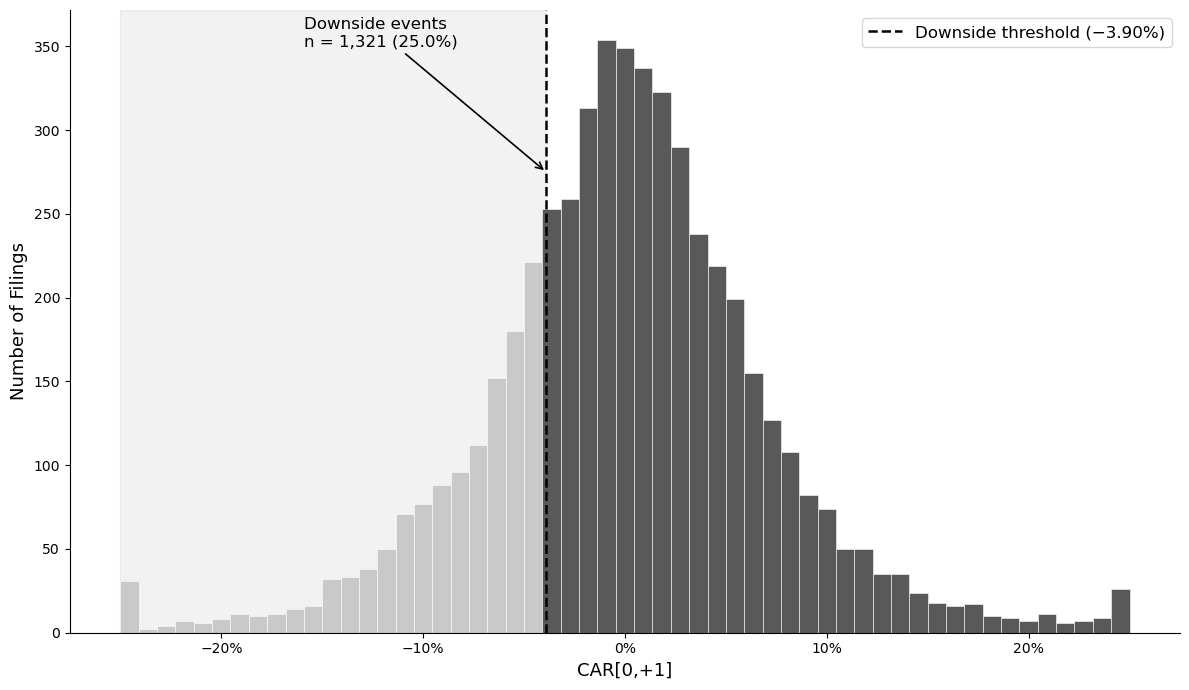

Threshold: -0.0390 (-3.90%)  |  Downside: 1,321 (25.0%)


In [18]:
# visualizing the distribution of cumulative abnormal returns 
car_col = 'car_0_1'
n_downside   = int(df_lm['downside'].sum())
pct_downside = df_lm['downside'].mean()
threshold    = df_lm.loc[df_lm['downside'] == 1, car_col].max()   # exact boundary of stored label
label_pct    = f"{threshold*100:.2f}".replace("-", "\u2212")

plot_data = df_lm[car_col].dropna().clip(-0.25, 0.25)

fig, ax = plt.subplots(figsize=(12, 7))
counts, bins, patches = ax.hist(plot_data, bins=55, edgecolor='white', linewidth=0.4)

bin_width = bins[1] - bins[0]
for patch, left_edge in zip(patches, bins[:-1]):
    center = left_edge + bin_width / 2
    patch.set_facecolor('#c9c9c9' if center < threshold else '#595959')

ax.axvspan(bins[0], threshold, color='black', alpha=0.05, zorder=0)
ax.axvline(threshold, color='black', linestyle='--', linewidth=1.8,
           label=f'Downside threshold ({label_pct}%)')

ax.annotate(f'Downside events\nn = {n_downside:,} ({pct_downside:.1%})',
            xy=(threshold, 275), xytext=(threshold - 0.12, 350),
            fontsize=12, ha='left',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

ax.set_xlabel('CAR[0,+1]', fontsize=13)
ax.set_ylabel('Number of Filings', fontsize=13)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=12, loc='upper right', frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_DIR / 'figure1_car_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Threshold: {threshold:.4f} ({threshold*100:.2f}%)  |  Downside: {n_downside:,} ({pct_downside:.1%})")

In [ ]:
def bootstrap_auc_ci(labels, scores, n_boot=1000, seed=42):
    '''This function computes a bootstrap confidence interval for the AUC metric. It takes in the true labels and predicted scores, performs bootstrap resampling, and 
    returns the 95% confidence interval for the AUC.'''
    np.random.seed(seed)
    boot_aucs = []
    df_tmp = pd.DataFrame({'label': labels, 'score': scores})
    for _ in range(n_boot):
        sample = df_tmp.sample(len(df_tmp), replace=True)
        try:
            boot_aucs.append(roc_auc_score(sample['label'], sample['score']))
        except:
            pass
    return np.percentile(boot_aucs, 2.5), np.percentile(boot_aucs, 97.5)

def bottom_decile_car(df, score_col, ascending=False):
    '''This function compares the average CAR in the bottom decile of filings ranked by a given sentiment score. It takes in a DataFrame, the name of the score column, 
    and whether to sort in ascending order (default is False for negative sentiment). It returns the average CAR for the bottom decile of filings.'''
    sorted_df = df.sort_values(score_col, ascending=ascending)
    n = int(len(sorted_df) * 0.10)
    return sorted_df.head(n)['car_0_1'].mean()

In [ ]:
results = []

# lm dictionary — full sample
auc          = roc_auc_score(df_lm['downside'], df_lm['lm_neg_prop'])
ci_lo, ci_hi = bootstrap_auc_ci(df_lm['downside'], df_lm['lm_neg_prop'])
spear        = spearmanr(df_lm['lm_neg_prop'], df_lm['car_0_1'])[0]
bdcar        = bottom_decile_car(df_lm, 'lm_neg_prop', ascending=False)
results.append({'Method': 'LM Dictionary', 'Sample': 'Full (5,280)',
                'AUC': auc, '95% CI': f'[{ci_lo:.3f}, {ci_hi:.3f}]',
                'Spearman r': spear, 'Bottom Decile CAR': bdcar})

# lm dictionary — evaluation subsample
auc          = roc_auc_score(lm_eval['downside'], lm_eval['lm_neg_prop'])
ci_lo, ci_hi = bootstrap_auc_ci(lm_eval['downside'], lm_eval['lm_neg_prop'])
spear        = spearmanr(lm_eval['lm_neg_prop'], lm_eval['car_0_1'])[0]
bdcar        = bottom_decile_car(lm_eval, 'lm_neg_prop', ascending=False)
results.append({'Method': 'LM Dictionary', 'Sample': 'Subsample (1,597)',
                'AUC': auc, '95% CI': f'[{ci_lo:.3f}, {ci_hi:.3f}]',
                'Spearman r': spear, 'Bottom Decile CAR': bdcar})

# FinBERT — full sample
auc          = roc_auc_score(df_finbert['downside'], df_finbert['finbert_neg_mean'])
ci_lo, ci_hi = bootstrap_auc_ci(df_finbert['downside'], df_finbert['finbert_neg_mean'])
spear        = spearmanr(df_finbert['finbert_neg_mean'], df_finbert['car_0_1'])[0]
bdcar        = bottom_decile_car(df_finbert, 'finbert_neg_mean', ascending=False)
results.append({'Method': 'FinBERT', 'Sample': 'Full (5,280)',
                'AUC': auc, '95% CI': f'[{ci_lo:.3f}, {ci_hi:.3f}]',
                'Spearman r': spear, 'Bottom Decile CAR': bdcar})

# FinBERT — evaluation subsample
auc          = roc_auc_score(finbert_eval['downside'], finbert_eval['finbert_neg_mean'])
ci_lo, ci_hi = bootstrap_auc_ci(finbert_eval['downside'], finbert_eval['finbert_neg_mean'])
spear        = spearmanr(finbert_eval['finbert_neg_mean'], finbert_eval['car_0_1'])[0]
bdcar        = bottom_decile_car(finbert_eval, 'finbert_neg_mean', ascending=False)
results.append({'Method': 'FinBERT', 'Sample': 'Subsample (1,597)',
                'AUC': auc, '95% CI': f'[{ci_lo:.3f}, {ci_hi:.3f}]',
                'Spearman r': spear, 'Bottom Decile CAR': bdcar})

# GPT-4o — evaluation subsample only
auc          = roc_auc_score(gpt_eval['downside'], -gpt_eval['gpt_score'])
ci_lo, ci_hi = bootstrap_auc_ci(gpt_eval['downside'], -gpt_eval['gpt_score'])
spear        = spearmanr(-gpt_eval['gpt_score'], gpt_eval['car_0_1'])[0]
bdcar        = bottom_decile_car(gpt_eval, 'gpt_score', ascending=True)
results.append({'Method': 'GPT-4o', 'Sample': 'Subsample (1,597)',
                'AUC': auc, '95% CI': f'[{ci_lo:.3f}, {ci_hi:.3f}]',
                'Spearman r': spear, 'Bottom Decile CAR': bdcar})

# displaying and saving the results
results_df = pd.DataFrame(results)
results_df['AUC']               = results_df['AUC'].round(4)
results_df['Spearman r']        = results_df['Spearman r'].round(4)
results_df['Bottom Decile CAR'] = results_df['Bottom Decile CAR'].round(4)

print(results_df.to_string(index=False))
results_df.to_csv(DATA_DIR / "results_summary.csv", index=False)
print(f"\nSaved to {DATA_DIR / 'results_summary.csv'}")

       Method            Sample    AUC         95% CI  Spearman r  Bottom Decile CAR
LM Dictionary      Full (5,280) 0.5046 [0.487, 0.521]     -0.0135            -0.0027
LM Dictionary Subsample (1,597) 0.5165 [0.486, 0.546]     -0.0206            -0.0308
      FinBERT      Full (5,280) 0.5235 [0.506, 0.541]     -0.0465            -0.0110
      FinBERT Subsample (1,597) 0.5130 [0.483, 0.540]     -0.0227            -0.0406
       GPT-4o Subsample (1,597) 0.5749 [0.545, 0.603]     -0.1519            -0.0503

Saved to Data download/data/results_summary.csv


In [ ]:
# implementing DeLong's test for comparing AUCs of two correlated ROC curves 
def delong_test(labels, scores1, scores2):
    """
    DeLong et al. (1988) test for comparing two correlated AUCs.
    Returns z-statistic and p-value.
    """
    def auc_variance(labels, scores):
        '''This function computes the AUC and its variance using Delong's method. It separates the stores into positive and negative classes, computes the V10 and V01 arrays, 
        and calculates the variance of the AUC estimate'''
        # separating scores into positive and negative classes
        pos = scores[labels == 1]
        neg = scores[labels == 0]
        n1, n0 = len(pos), len(neg) 
        # computing V10 and V01 arrays
        v10 = np.array([np.mean(p > neg) + 0.5 * np.mean(p == neg) for p in pos])
        v01 = np.array([np.mean(n < pos) + 0.5 * np.mean(n == pos) for n in neg])
        var = (np.var(v10, ddof=1) / n1) + (np.var(v01, ddof=1) / n0)
        return np.mean(v10), var

    labels  = np.array(labels)
    scores1 = np.array(scores1)
    scores2 = np.array(scores2)
    # computing AUCs and variances for both sets of scores
    auc1, var1 = auc_variance(labels, scores1)
    auc2, var2 = auc_variance(labels, scores2)

    pos_idx = np.where(labels == 1)[0]
    neg_idx = np.where(labels == 0)[0]
    n1, n0  = len(pos_idx), len(neg_idx)
    # computing covariance between the two AUC estimates
    v10_1 = np.array([np.mean(scores1[pos_idx[i]] > scores1[neg_idx]) for i in range(n1)])
    v10_2 = np.array([np.mean(scores2[pos_idx[i]] > scores2[neg_idx]) for i in range(n1)])
    v01_1 = np.array([np.mean(scores1[neg_idx[i]] < scores1[pos_idx]) for i in range(n0)])
    v01_2 = np.array([np.mean(scores2[neg_idx[i]] < scores2[pos_idx]) for i in range(n0)])

    cov = (np.cov(v10_1, v10_2)[0,1] / n1) + (np.cov(v01_1, v01_2)[0,1] / n0)

    z = (auc1 - auc2) / np.sqrt(var1 + var2 - 2 * cov)
    from scipy.stats import norm
    p = 2 * norm.sf(abs(z))
    return auc1, auc2, z, p

# running pairwise DeLong tests on evaluation subsample
print("=== DeLong Test for Pairwise AUC Differences (Evaluation Subsample, N=1,597) ===\n")

# aligning all three methods on the common evaluation subsample
common_acc     = gpt_eval_acc & set(lm_eval['accessionNumber']) & set(finbert_eval['accessionNumber'])
lm_common      = lm_eval[lm_eval['accessionNumber'].isin(common_acc)].sort_values('accessionNumber')
finbert_common = finbert_eval[finbert_eval['accessionNumber'].isin(common_acc)].sort_values('accessionNumber')
gpt_common     = gpt_eval[gpt_eval['accessionNumber'].isin(common_acc)].sort_values('accessionNumber')

labels = lm_common['downside'].values

pairs = [
    ('GPT-4o',  -gpt_common['gpt_score'].values,        'LM Dictionary', lm_common['lm_neg_prop'].values),
    ('GPT-4o',  -gpt_common['gpt_score'].values,        'FinBERT',       finbert_common['finbert_neg_mean'].values),
    ('FinBERT',  finbert_common['finbert_neg_mean'].values, 'LM Dictionary', lm_common['lm_neg_prop'].values),
]

for name1, scores1, name2, scores2 in pairs:
    auc1, auc2, z, p = delong_test(labels, scores1, scores2)
    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    print(f"  {name1} (AUC={auc1:.4f}) vs {name2} (AUC={auc2:.4f})")
    print(f"  z = {z:.3f},  p = {p:.4f}  {stars}")
    print()

=== DeLong Test for Pairwise AUC Differences (Evaluation Subsample, N=1,597) ===

  GPT-4o (AUC=0.5749) vs LM Dictionary (AUC=0.5165)
  z = 3.118,  p = 0.0018  **

  GPT-4o (AUC=0.5749) vs FinBERT (AUC=0.5130)
  z = 4.154,  p = 0.0000  ***

  FinBERT (AUC=0.5130) vs LM Dictionary (AUC=0.5165)
  z = -0.209,  p = 0.8345  n.s.



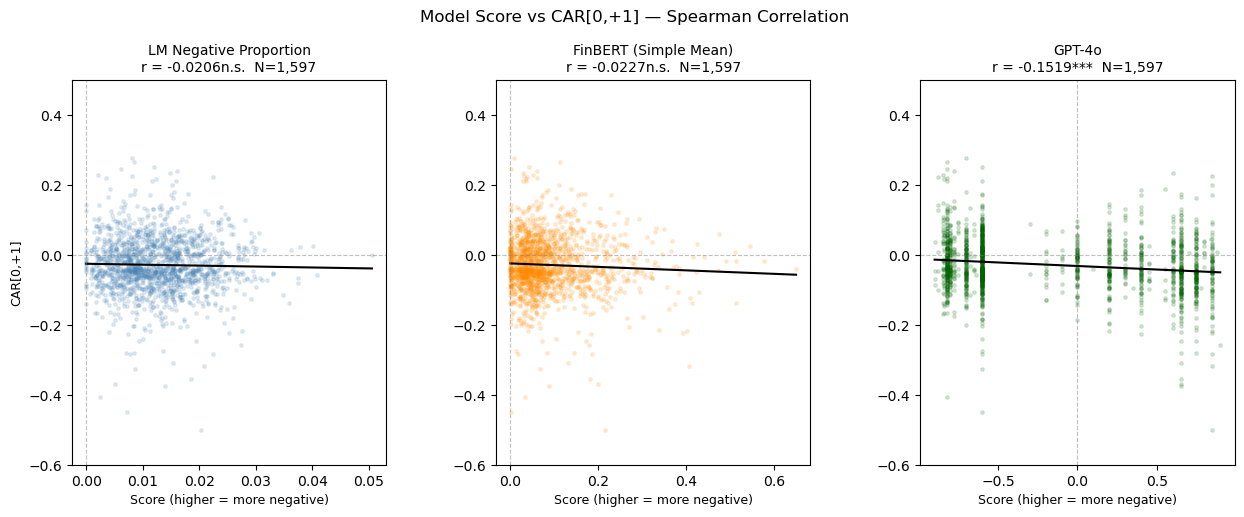

Saved to Data download/data/scatterplot_scores_vs_car.png


In [ ]:
# merging all three on common evaluation subsample for plotting
df_plot = lm_eval[['accessionNumber', 'car_0_1', 'downside', 'lm_neg_prop']].merge(
    finbert_eval[['accessionNumber', 'finbert_neg_mean']], on='accessionNumber'
).merge(
    gpt_eval[['accessionNumber', 'gpt_score']], on='accessionNumber'
)

# creating scatterplots of each model's score vs CAR[0,+1], with Spearman correlation
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, wspace=0.35)

plot_configs = [
    ('LM Negative Proportion', 'lm_neg_prop',     +1, 'steelblue'),
    ('FinBERT (Simple Mean)',   'finbert_neg_mean', +1, 'darkorange'),
    ('GPT-4o',                 'gpt_score',        -1, 'darkgreen'),
]

for i, (name, col, direction, color) in enumerate(plot_configs):
    ax   = fig.add_subplot(gs[0, i])
    mask = df_plot[col].notna() & df_plot['car_0_1'].notna()
    x    = df_plot.loc[mask, col] * direction
    y    = df_plot.loc[mask, 'car_0_1']
    n    = mask.sum()

    r, p  = stats.spearmanr(x, y)
    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))

    ax.scatter(x, y, alpha=0.15, s=6, color=color, rasterized=True)

    z     = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, np.poly1d(z)(xline), color='black', lw=1.5)

    ax.axhline(0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', lw=0.8, linestyle='--', alpha=0.5)

    ax.set_title(f'{name}\nr = {r:.4f}{stars}  N={n:,}', fontsize=10)
    ax.set_xlabel('Score (higher = more negative)', fontsize=9)
    ax.set_ylabel('CAR[0,+1]' if i == 0 else '', fontsize=9)
    ax.set_ylim(-0.6, 0.5)

plt.suptitle('Model Score vs CAR[0,+1] — Spearman Correlation', fontsize=12, y=1.02)
plt.savefig(DATA_DIR / 'scatterplot_scores_vs_car.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {DATA_DIR / 'scatterplot_scores_vs_car.png'}")

In [ ]:
# Table 3: Pairwise Spearman Correlations Between Sentiment Scores 
# All computed on evaluation subsample (1597 filings) where all three methods exist
# GPT score negated so higher = more negative, consistent with other methods

# merging all three methods on common evaluation subsample
df_corr = lm_eval[['accessionNumber', 'lm_neg_prop']].merge(
    finbert_eval[['accessionNumber', 'finbert_neg_mean']], on='accessionNumber'
).merge(
    gpt_eval[['accessionNumber', 'gpt_score']], on='accessionNumber'
)

# align directions: higher = more negative for all three
df_corr['gpt_neg'] = -df_corr['gpt_score']

methods = [
    ('LM Negative Proportion', 'lm_neg_prop'),
    ('FinBERT (Simple Mean)',   'finbert_neg_mean'),
    ('GPT-4o',                 'gpt_neg'),
]

# building symmetric correlation matrix
n = len(methods)
table3 = pd.DataFrame(index=[m[0] for m in methods], columns=[m[0] for m in methods])

for i, (name_i, col_i) in enumerate(methods):
    for j, (name_j, col_j) in enumerate(methods):
        if i == j:
            table3.loc[name_i, name_j] = '1.000'
        elif j > i:
            r, p = spearmanr(df_corr[col_i], df_corr[col_j])
            stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
            table3.loc[name_i, name_j] = f'{r:.3f}{stars}'
        else:
            table3.loc[name_i, name_j] = ''  # leave lower triangle blank

print("Table 3. Pairwise Spearman Correlations Between Sentiment Scores\n")
print(table3.to_string())
print(f"\nNote: All correlations computed on the evaluation subsample (N={len(df_corr):,}).")
print("*** p<0.001    ** p<0.01    * p<0.05")

table3.to_csv(DATA_DIR / "table3_pairwise_correlations.csv")
print(f"\nSaved to {DATA_DIR / 'table3_pairwise_correlations.csv'}")

Table 3. Pairwise Spearman Correlations Between Sentiment Scores

                       LM Negative Proportion FinBERT (Simple Mean)    GPT-4o
LM Negative Proportion                  1.000              0.298***  0.140***
FinBERT (Simple Mean)                                         1.000  0.441***
GPT-4o                                                                  1.000

Note: All correlations computed on the evaluation subsample (N=1,597).
*** p<0.001    ** p<0.01    * p<0.05

Saved to Data download/data/table3_pairwise_correlations.csv


In [ ]:
# Table 4: AUC Estimates by Method 

# LM Dictionary
lm_full_auc         = roc_auc_score(df_lm['downside'], df_lm['lm_neg_prop'])
lm_eval_auc         = roc_auc_score(lm_eval['downside'], lm_eval['lm_neg_prop'])
lm_ci_lo, lm_ci_hi = bootstrap_auc_ci(lm_eval['downside'], lm_eval['lm_neg_prop'])

# FinBERT (Simple Mean)
fb_full_auc         = roc_auc_score(df_finbert['downside'], df_finbert['finbert_neg_mean'])
fb_eval_auc         = roc_auc_score(finbert_eval['downside'], finbert_eval['finbert_neg_mean'])
fb_ci_lo, fb_ci_hi = bootstrap_auc_ci(finbert_eval['downside'], finbert_eval['finbert_neg_mean'])

# GPT-4o
gpt_eval_auc          = roc_auc_score(gpt_eval['downside'], -gpt_eval['gpt_score'])
gpt_ci_lo, gpt_ci_hi = bootstrap_auc_ci(gpt_eval['downside'], -gpt_eval['gpt_score'])

# Build table
table4 = pd.DataFrame([
    {
        'Method'         : 'LM Negative Proportion',
        'Full Sample AUC': round(lm_full_auc, 4),
        'Subsample AUC'  : round(lm_eval_auc, 4),
        '95% CI'         : f'[{lm_ci_lo:.3f}, {lm_ci_hi:.3f}]',
    },
    {
        'Method'         : 'FinBERT (Simple Mean)',
        'Full Sample AUC': round(fb_full_auc, 4),
        'Subsample AUC'  : round(fb_eval_auc, 4),
        '95% CI'         : f'[{fb_ci_lo:.3f}, {fb_ci_hi:.3f}]',
    },
    {
        'Method'         : 'GPT-4o',
        'Full Sample AUC': '—',
        'Subsample AUC'  : round(gpt_eval_auc, 4),
        '95% CI'         : f'[{gpt_ci_lo:.3f}, {gpt_ci_hi:.3f}]',
    },
])

print("Table 4. AUC Estimates by Method\n")
print(table4.to_string(index=False))
table4.to_csv(DATA_DIR / "table4_auc_estimates.csv", index=False)
print(f"\nSaved to {DATA_DIR / 'table4_auc_estimates.csv'}")

Table 4. AUC Estimates by Method

                Method Full Sample AUC  Subsample AUC         95% CI
LM Negative Proportion          0.5046         0.5165 [0.486, 0.546]
 FinBERT (Simple Mean)          0.5235         0.5130 [0.483, 0.540]
                GPT-4o               —         0.5749 [0.545, 0.603]

Saved to Data download/data/table4_auc_estimates.csv


In [ ]:
# Table 5: Spearman Rank Correlation with Continuous CAR[0,+1] 
# All computed on evaluation subsample (1597 filings) for consistency
# GPT score negated so higher = more negative, consistent with other methods

pairs = [
    ('LM Negative Proportion', lm_eval['lm_neg_prop'],           lm_eval['car_0_1'],      +1),
    ('FinBERT (Simple Mean)',   finbert_eval['finbert_neg_mean'],  finbert_eval['car_0_1'], +1),
    ('GPT-4o',                 gpt_eval['gpt_score'],             gpt_eval['car_0_1'],     -1),
]

rows = []
for name, scores, car, direction in pairs:
    r, p = spearmanr(scores * direction, car)
    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    rows.append({
        'Method'  : name,
        'ρ'       : round(r, 4),
        'p-value' : f'{p:.4f} {stars}',
    })

table5 = pd.DataFrame(rows)
print("Table 5. Spearman Rank Correlation with Continuous CAR[0,+1]\n")
print(table5.to_string(index=False))
print("\nNote: All correlations computed on the evaluation subsample (N=1,597).")
print("Negative ρ indicates more negative sentiment score predicts more negative return.")

table5.to_csv(DATA_DIR / "table5_spearman.csv", index=False)
print(f"\nSaved to {DATA_DIR / 'table5_spearman.csv'}")

Table 5. Spearman Rank Correlation with Continuous CAR[0,+1]

                Method       ρ     p-value
LM Negative Proportion -0.0206 0.4102 n.s.
 FinBERT (Simple Mean) -0.0227 0.3641 n.s.
                GPT-4o -0.1519  0.0000 ***

Note: All correlations computed on the evaluation subsample (N=1,597).
Negative ρ indicates more negative sentiment score predicts more negative return.

Saved to Data download/data/table5_spearman.csv


In [ ]:
# Table 6: Mean CAR[0,+1] of Bottom Sentiment Decile 

full_mean_car = lm_eval['car_0_1'].mean()  # same for all methods since same evaluation subsample

def bottom_decile_mean_car(df, score_col, ascending=False):
    sorted_df = df.sort_values(score_col, ascending=ascending)
    n = int(len(sorted_df) * 0.10)
    return sorted_df.head(n)['car_0_1'].mean()

lm_bot  = bottom_decile_mean_car(lm_eval,      'lm_neg_prop',      ascending=False)
fb_bot  = bottom_decile_mean_car(finbert_eval,  'finbert_neg_mean',  ascending=False)
gpt_bot = bottom_decile_mean_car(gpt_eval,      'gpt_score',         ascending=True)

table6 = pd.DataFrame([
    {
        'Method'                  : 'LM Negative Proportion',
        'Bottom Decile Mean CAR'  : f'{lm_bot:.2%}',
        'Full Subsample Mean CAR' : f'{full_mean_car:.2%}',
        'Difference'              : f'{lm_bot - full_mean_car:.2%}',
    },
    {
        'Method'                  : 'FinBERT (Simple Mean)',
        'Bottom Decile Mean CAR'  : f'{fb_bot:.2%}',
        'Full Subsample Mean CAR' : f'{full_mean_car:.2%}',
        'Difference'              : f'{fb_bot - full_mean_car:.2%}',
    },
    {
        'Method'                  : 'GPT-4o',
        'Bottom Decile Mean CAR'  : f'{gpt_bot:.2%}',
        'Full Subsample Mean CAR' : f'{full_mean_car:.2%}',
        'Difference'              : f'{gpt_bot - full_mean_car:.2%}',
    },
])

print("Table 6. Mean CAR[0,+1] of Bottom Sentiment Decile\n")
print(table6.to_string(index=False))
print(f"\nNote: Bottom decile defined as lowest-scoring 10% of filings by each method's score (N=159).")
print(f"Full evaluation subsample mean CAR = {full_mean_car:.2%}")

table6.to_csv(DATA_DIR / "table6_bottom_decile.csv", index=False)
print(f"Saved to {DATA_DIR / 'table6_bottom_decile.csv'}")

Table 6. Mean CAR[0,+1] of Bottom Sentiment Decile

                Method Bottom Decile Mean CAR Full Subsample Mean CAR Difference
LM Negative Proportion                 -3.08%                  -2.92%     -0.17%
 FinBERT (Simple Mean)                 -4.06%                  -2.92%     -1.14%
                GPT-4o                 -5.03%                  -2.92%     -2.11%

Note: Bottom decile defined as lowest-scoring 10% of filings by each method's score (N=159).
Full evaluation subsample mean CAR = -2.92%
Saved to Data download/data/table6_bottom_decile.csv


In [ ]:
# section 5.1: Descriptive Statistics
print("="*70)
print("SECTION 5.1 — DESCRIPTIVE STATISTICS")
print("="*70)

# LM Negative Word Proportion (full sample, N=5,280) 
print("\n── Loughran-McDonald — Negative Word Proportion ──")
lm_neg = df_lm['lm_neg_prop'].dropna()
print(f"  [LM_MIN]      = {lm_neg.min():.4f}")
print(f"  [LM_MAX]      = {lm_neg.max():.4f}")
print(f"  [LM_MEAN]     = {lm_neg.mean():.4f}")
print(f"  [LM_SD]       = {lm_neg.std():.4f}")
print(f"  Skewness      = {lm_neg.skew():.3f}  (positive = right-skewed)")

# LM Net Sentiment Ratio 
print("\n── Loughran-McDonald — Net Sentiment Ratio ──")
if 'lm_net_sentiment' in df_lm.columns:
    lm_net_col = 'lm_net_sentiment'
elif 'lm_net' in df_lm.columns:
    lm_net_col = 'lm_net'
else:
    candidates = [c for c in df_lm.columns if 'net' in c.lower() or 'lm_pos' in c.lower()]
    print(f"  ⚠ Net sentiment column not found. Candidates: {candidates}")
    lm_net_col = None

if lm_net_col:
    lm_net = df_lm[lm_net_col].dropna()
    print(f"  [LM_NET_MEAN] = {lm_net.mean():.4f}")

# FinBERT — Simple Mean of Sentence-Level Negative Probabilities 
print("\n── FinBERT — Simple Mean (full sample, N=5,280) ──")
fb_neg = df_finbert['finbert_neg_mean'].dropna()
print(f"  [FB_MIN]      = {fb_neg.min():.4f}")
print(f"  [FB_MAX]      = {fb_neg.max():.4f}")
print(f"  [FB_MEAN]     = {fb_neg.mean():.4f}")
print(f"  [FB_SD]       = {fb_neg.std():.4f}")
print(f"  Skewness      = {fb_neg.skew():.3f}  "
      f"({'right-skewed' if fb_neg.skew() > 0.5 else 'left-skewed' if fb_neg.skew() < -0.5 else 'approximately symmetric'})")

# FinBERT — Sentence counts per filing (full sample, N=5,280) 
print("\n── FinBERT — Sentence Counts per Filing ──")
sent = df_finbert['finbert_n_sentences'].dropna()
print(f"  [SENT_MIN]    = {int(sent.min())}")
print(f"  [SENT_MAX]    = {int(sent.max())}")
print(f"  [SENT_MEDIAN] = {int(sent.median())}")

# GPT-4o — Scores on the held-out evaluation subsample (N=1,597) 
print("\n── GPT-4o — Scores (evaluation subsample, N=1,597) ──")
gpt_scores = gpt_eval['gpt_score'].dropna()
print(f"  [GPT_MIN]     = {gpt_scores.min():.4f}")
print(f"  [GPT_MAX]     = {gpt_scores.max():.4f}")
print(f"  [GPT_MEAN]    = {gpt_scores.mean():.4f}")
print(f"  [GPT_SD]      = {gpt_scores.std():.4f}")

near_zero = ((gpt_scores >= -0.05) & (gpt_scores <= 0.05)).sum()
near_zero_pct = 100 * near_zero / len(gpt_scores)
print(f"  [GPT_NEAR_ZERO_PCT] = {near_zero_pct:.1f}%  "
      f"({near_zero} of {len(gpt_scores)} filings within [−0.05, +0.05])")

SECTION 5.1 — DESCRIPTIVE STATISTICS

── Loughran-McDonald — Negative Word Proportion ──
  [LM_MIN]      = 0.0000
  [LM_MAX]      = 0.0506
  [LM_MEAN]     = 0.0124
  [LM_SD]       = 0.0069
  Skewness      = 0.592  (positive = right-skewed)

── Loughran-McDonald — Net Sentiment Ratio ──
  [LM_NET_MEAN] = 0.0009

── FinBERT — Simple Mean (full sample, N=5,280) ──
  [FB_MIN]      = 0.0000
  [FB_MAX]      = 0.6746
  [FB_MEAN]     = 0.0832
  [FB_SD]       = 0.0818
  Skewness      = 2.112  (right-skewed)

── FinBERT — Sentence Counts per Filing ──
  [SENT_MIN]    = 1
  [SENT_MAX]    = 422
  [SENT_MEDIAN] = 55

── GPT-4o — Scores (evaluation subsample, N=1,597) ──
  [GPT_MIN]     = -0.9000
  [GPT_MAX]     = 0.9000
  [GPT_MEAN]    = 0.1509
  [GPT_SD]      = 0.6319
  [GPT_NEAR_ZERO_PCT] = 4.8%  (76 of 1597 filings within [−0.05, +0.05])


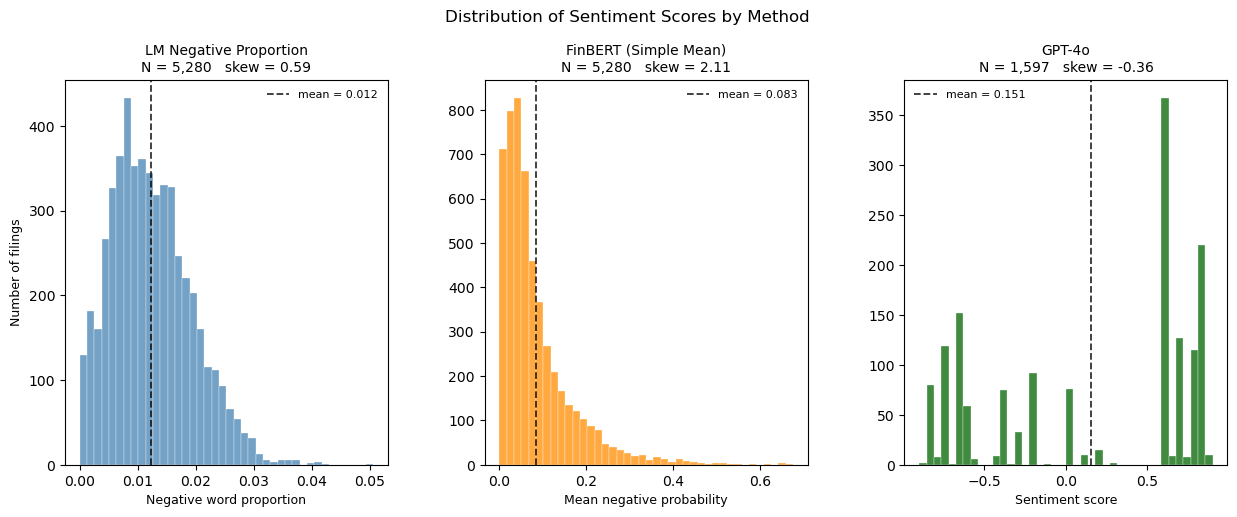

Saved to Data download/data/distribution_sentiment_scores.png


In [ ]:
# Figure: Distribution of Sentiment Scores by Method (Section 5.1) 
# LM and FinBERT shown on full sample (N=5,280); GPT-4o on evaluation subsample (N=1,597), matching the descriptive statistics reported in the text. Each method is 
# plotted on its native scale, so axes differ across panels.

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, wspace=0.30)

# (name, data series, color, native-scale x-label)
dist_configs = [
    ('LM Negative Proportion', df_lm['lm_neg_prop'].dropna(),
     'steelblue',  'Negative word proportion'),
    ('FinBERT (Simple Mean)',   df_finbert['finbert_neg_mean'].dropna(),
     'darkorange', 'Mean negative probability'),
    ('GPT-4o',                 gpt_eval['gpt_score'].dropna(),
     'darkgreen',  'Sentiment score'),
]

for i, (name, series, color, xlabel) in enumerate(dist_configs):
    ax   = fig.add_subplot(gs[0, i])
    n    = len(series)
    mean = series.mean()
    skew = series.skew()

    ax.hist(series, bins=40, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(mean, color='black', lw=1.3, linestyle='--', alpha=0.8,
               label=f'mean = {mean:.3f}')

    ax.set_title(f'{name}\nN = {n:,}   skew = {skew:.2f}', fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Number of filings' if i == 0 else '', fontsize=9)
    ax.legend(fontsize=8, frameon=False)

plt.suptitle('Distribution of Sentiment Scores by Method', fontsize=12, y=1.02)
plt.savefig(DATA_DIR / 'distribution_sentiment_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {DATA_DIR / 'distribution_sentiment_scores.png'}")